In [ ]:
# Superstore Sales & Profitability Analysis

This notebook explores sales and profitability patterns in the Superstore dataset.
The goal is to identify which categories, sub-categories, and order types drive profit
and which contribute to losses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Data Loading & Initial Inspection

In [2]:
df = pd.read_csv("data/superstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [7]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [19]:
df.groupby('Ship Mode')['Sales'].sum()


Ship Mode
First Class       3.514284e+05
Same Day          1.283631e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64

In [21]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [24]:
df.groupby('Ship Mode')['Profit'].sum()


Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64

In [27]:
df.groupby('Ship Mode')['Profit'].mean().sort_values(ascending = False)


Ship Mode
First Class       31.839948
Second Class      29.535545
Same Day          29.266591
Standard Class    27.494770
Name: Profit, dtype: float64

In [29]:
df.groupby('Ship Mode')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending = False)

,Sales,Profit
Ship Mode,,
First Class,228.497024,31.839948
Second Class,236.089239,29.535545
Same Day,236.396179,29.266591
Standard Class,227.583067,27.494770


In [43]:
grouped_df =df.groupby('Ship Mode').agg(
    orders =('Ship Mode', 'size'), 
    avg_profit = ('Profit', 'mean'),
    total_profit = ('Profit', 'sum')
).sort_values(by='avg_profit')


In [46]:
grouped_df['Profit_per_order'] = grouped_df['total_profit'] / grouped_df['orders']
grouped_df.sort_values(by= 'Profit_per_order', ascending= False)

,orders,avg_profit,total_profit,Profit_per_order
Ship Mode,,,,
First Class,1538,31.839948,48969.8399,31.839948
Second Class,1945,29.535545,57446.6354,29.535545
Same Day,543,29.266591,15891.7589,29.266591
Standard Class,5968,27.494770,164088.7875,27.494770


In [47]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [53]:
df.groupby(['Category', 'Sub-Category'])['Profit'].mean().sort_values(ascending= False)

Category         Sub-Category
Technology       Copiers         817.909190
                 Accessories      54.111788
                 Phones           50.073938
Furniture        Chairs           43.095894
Office Supplies  Appliances       38.922758
Technology       Machines         29.432669
Office Supplies  Envelopes        27.418019
                 Storage          25.152277
                 Paper            24.856620
                 Binders          19.843574
                 Labels           15.236962
Furniture        Furnishings      13.645918
Office Supplies  Art               8.200737
                 Fasteners         4.375660
                 Supplies         -6.258418
Furniture        Bookcases       -15.230509
                 Tables          -55.565771
Name: Profit, dtype: float64

In [71]:
df.sort_values(by='Profit', ascending=False).head(10)[
    [ 'Category', 'Sub-Category', 'Sales', 'Profit']
    ]

,Category,Sub-Category,Sales,Profit
6826,Technology,Copiers,17499.950,8399.9760
8153,Technology,Copiers,13999.960,6719.9808
4190,Technology,Copiers,10499.970,5039.9856
9039,Office Supplies,Binders,9892.740,4946.3700
4098,Office Supplies,Binders,9449.950,4630.4755
2623,Technology,Copiers,11199.968,3919.9888
509,Office Supplies,Binders,6354.950,3177.4750
8488,Technology,Machines,8749.950,2799.9840
7666,Technology,Copiers,5399.910,2591.9568
6520,Office Supplies,Binders,5443.960,2504.2216


In [67]:
df['Profit'].sort_values(ascending=False).head(10)

6826    8399.9760
8153    6719.9808
4190    5039.9856
9039    4946.3700
4098    4630.4755
2623    3919.9888
509     3177.4750
8488    2799.9840
7666    2591.9568
6520    2504.2216
Name: Profit, dtype: float64

In [76]:
df[(df['Profit']< 0) & (df['Sales'] > df['Sales'].mean())]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
38,Standard Class,Home Office,United States,Houston,Texas,77041,Central,Furniture,Bookcases,532.3992,3,0.32,-46.9764
72,Standard Class,Consumer,United States,Memphis,Tennessee,38109,South,Furniture,Chairs,831.9360,8,0.20,-114.3912
84,First Class,Home Office,United States,Chicago,Illinois,60623,Central,Office Supplies,Storage,230.3760,3,0.20,-48.9549
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9899,Standard Class,Home Office,United States,Springfield,Ohio,45503,East,Furniture,Tables,330.5880,1,0.40,-143.2548
9912,First Class,Corporate,United States,Santa Barbara,California,93101,West,Furniture,Chairs,362.1360,3,0.20,-54.3204
9919,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Furniture,Chairs,528.4300,5,0.30,-143.4310
9931,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960


In [77]:
df.groupby('Category')['Profit'].mean()

Category
Furniture           8.699327
Office Supplies    20.327050
Technology         78.752002
Name: Profit, dtype: float64

In [78]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [81]:
df.groupby('Category')['Category'].size()

Category
Furniture          2121
Office Supplies    6026
Technology         1847
Name: Category, dtype: int64

In [82]:
df.groupby('Category')['Profit'].count()

Category
Furniture          2121
Office Supplies    6026
Technology         1847
Name: Profit, dtype: int64

In [83]:
df.groupby('Category')['Profit'].size()

Category
Furniture          2121
Office Supplies    6026
Technology         1847
Name: Profit, dtype: int64

In [84]:
df.groupby('Category').size()

Category
Furniture          2121
Office Supplies    6026
Technology         1847
dtype: int64

In [93]:
df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

In [96]:
df.assign(profit_margin= df['Profit'] / df['Sales']).groupby('Sub-Category')['profit_margin'].mean().sort_values(ascending= False)


Sub-Category
Labels         0.429663
Paper          0.425600
Envelopes      0.423140
Copiers        0.317194
Fasteners      0.299171
Art            0.251646
Accessories    0.218210
Furnishings    0.137066
Phones         0.119222
Supplies       0.112039
Storage        0.089113
Chairs         0.043900
Machines      -0.072026
Bookcases     -0.126640
Tables        -0.147727
Appliances    -0.156869
Binders       -0.199595
Name: profit_margin, dtype: float64

In [99]:
df.shape


(9994, 13)

In [100]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [101]:
df.loc[df['Sales']> 500]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
10,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
11,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9931,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960
9942,Standard Class,Consumer,United States,Anaheim,California,92804,West,Office Supplies,Storage,998.8200,9,0.00,29.9646
9947,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Furniture,Chairs,1925.8800,6,0.00,539.2464
9948,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Office Supplies,Appliances,2405.2000,8,0.00,793.7160


In [102]:
df[df['Sales'] > 500]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
10,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
11,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9931,Standard Class,Consumer,United States,San Bernardino,California,92404,West,Furniture,Bookcases,683.3320,4,0.15,-40.1960
9942,Standard Class,Consumer,United States,Anaheim,California,92804,West,Office Supplies,Storage,998.8200,9,0.00,29.9646
9947,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Furniture,Chairs,1925.8800,6,0.00,539.2464
9948,Second Class,Corporate,United States,Indianapolis,Indiana,46203,Central,Office Supplies,Appliances,2405.2000,8,0.00,793.7160


In [105]:
df[(df['Sales']>500) & (df['Profit']<0)]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
38,Standard Class,Home Office,United States,Houston,Texas,77041,Central,Furniture,Bookcases,532.3992,3,0.32,-46.9764
72,Standard Class,Consumer,United States,Memphis,Tennessee,38109,South,Furniture,Chairs,831.9360,8,0.20,-114.3912
124,Second Class,Home Office,United States,Houston,Texas,77041,Central,Furniture,Chairs,600.5580,3,0.30,-8.5794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,Standard Class,Consumer,United States,Houston,Texas,77070,Central,Furniture,Chairs,600.5580,3,0.30,-8.5794
9816,Standard Class,Corporate,United States,Saint Petersburg,Florida,33710,South,Office Supplies,Storage,516.9600,4,0.20,-6.4620
9876,First Class,Home Office,United States,Cleveland,Ohio,44105,East,Office Supplies,Storage,848.5440,4,0.20,-21.2136
9919,Standard Class,Corporate,United States,Bryan,Texas,77803,Central,Furniture,Chairs,528.4300,5,0.30,-143.4310


In [106]:
df[(df['Profit']<0)][['Category', 'Sub-Category', 'Sales', 'Profit']]

,Category,Sub-Category,Sales,Profit
3,Furniture,Tables,957.5775,-383.0310
14,Office Supplies,Appliances,68.8100,-123.8580
15,Office Supplies,Binders,2.5440,-3.8160
23,Furniture,Chairs,71.3720,-1.0196
27,Furniture,Bookcases,3083.4300,-1665.0522
...,...,...,...,...
9920,Office Supplies,Binders,22.3860,-35.8176
9921,Office Supplies,Binders,5.7420,-4.5936
9931,Furniture,Bookcases,683.3320,-40.1960
9937,Furniture,Tables,71.0880,-1.7772


In [108]:
df.loc[df['Profit'] < 0 , ['Category', 'Sub-Category', 'Sales', 'Profit']]

,Category,Sub-Category,Sales,Profit
3,Furniture,Tables,957.5775,-383.0310
14,Office Supplies,Appliances,68.8100,-123.8580
15,Office Supplies,Binders,2.5440,-3.8160
23,Furniture,Chairs,71.3720,-1.0196
27,Furniture,Bookcases,3083.4300,-1665.0522
...,...,...,...,...
9920,Office Supplies,Binders,22.3860,-35.8176
9921,Office Supplies,Binders,5.7420,-4.5936
9931,Furniture,Bookcases,683.3320,-40.1960
9937,Furniture,Tables,71.0880,-1.7772


In [128]:
df.iloc[:10, :5]

,Ship Mode,Segment,Country,City,State
0,Second Class,Consumer,United States,Henderson,Kentucky
1,Second Class,Consumer,United States,Henderson,Kentucky
2,Second Class,Corporate,United States,Los Angeles,California
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida
5,Standard Class,Consumer,United States,Los Angeles,California
6,Standard Class,Consumer,United States,Los Angeles,California
7,Standard Class,Consumer,United States,Los Angeles,California
8,Standard Class,Consumer,United States,Los Angeles,California
9,Standard Class,Consumer,United States,Los Angeles,California


In [ ]:
df.loc[(df['Category'] == 'Furniture'), ['Sales', 'Profit']]

,Sales,Profit
0,261.9600,41.9136
1,731.9400,219.5820
3,957.5775,-383.0310
5,48.8600,14.1694
10,1706.1840,85.3092
...,...,...
9962,383.4656,-67.6704
9964,13.4000,6.4320
9980,85.9800,22.3548
9989,25.2480,4.1028


In [133]:
df[['Sales']]

,Sales
0,261.9600
1,731.9400
2,14.6200
3,957.5775
4,22.3680
...,...
9989,25.2480
9990,91.9600
9991,258.5760
9992,29.6000


In [137]:
df[['Category', 'Sub-Category', 'Sales', 'Profit']] \
    .sort_values(by= 'Profit', ascending=False) \
        .head(10)

,Category,Sub-Category,Sales,Profit
6826,Technology,Copiers,17499.950,8399.9760
8153,Technology,Copiers,13999.960,6719.9808
4190,Technology,Copiers,10499.970,5039.9856
9039,Office Supplies,Binders,9892.740,4946.3700
4098,Office Supplies,Binders,9449.950,4630.4755
2623,Technology,Copiers,11199.968,3919.9888
509,Office Supplies,Binders,6354.950,3177.4750
8488,Technology,Machines,8749.950,2799.9840
7666,Technology,Copiers,5399.910,2591.9568
6520,Office Supplies,Binders,5443.960,2504.2216


In [138]:
df[['Category', 'Sub-Category', 'Sales', 'Profit']] \
    .sort_values(by= 'Profit') \
        .head(5)

,Category,Sub-Category,Sales,Profit
7772,Technology,Machines,4499.985,-6599.9780
683,Technology,Machines,7999.980,-3839.9904
9774,Office Supplies,Binders,2177.584,-3701.8928
3011,Technology,Machines,2549.985,-3399.9800
4991,Office Supplies,Binders,1889.990,-2929.4845


In [149]:
df.loc[(df['Sales'] > df['Sales'].mean()) & (df['Profit'] < 0)] \
    [['Category', 'Sub-Category', 'Sales', 'Profit']]

,Category,Sub-Category,Sales,Profit
3,Furniture,Tables,957.5775,-383.0310
27,Furniture,Bookcases,3083.4300,-1665.0522
38,Furniture,Bookcases,532.3992,-46.9764
72,Furniture,Chairs,831.9360,-114.3912
84,Office Supplies,Storage,230.3760,-48.9549
...,...,...,...,...
9899,Furniture,Tables,330.5880,-143.2548
9912,Furniture,Chairs,362.1360,-54.3204
9919,Furniture,Chairs,528.4300,-143.4310
9931,Furniture,Bookcases,683.3320,-40.1960


In [156]:
df.groupby('Sub-Category').size()

Sub-Category
Accessories     775
Appliances      466
Art             796
Binders        1523
Bookcases       228
Chairs          617
Copiers          68
Envelopes       254
Fasteners       217
Furnishings     957
Labels          364
Machines        115
Paper          1370
Phones          889
Storage         846
Supplies        190
Tables          319
dtype: int64

In [165]:
grouped = df.groupby('Sub-Category').agg(
    order_count=('Profit', 'size'),
    avg_profit=('Profit', 'mean')
)

result = grouped[grouped['order_count'] >= 50] \
    .sort_values(by='avg_profit', ascending=False)['avg_profit']
result

Sub-Category
Copiers        817.909190
Accessories     54.111788
Phones          50.073938
Chairs          43.095894
Appliances      38.922758
Machines        29.432669
Envelopes       27.418019
Storage         25.152277
Paper           24.856620
Binders         19.843574
Labels          15.236962
Furnishings     13.645918
Art              8.200737
Fasteners        4.375660
Supplies        -6.258418
Bookcases      -15.230509
Tables         -55.565771
Name: avg_profit, dtype: float64

In [181]:
grouped= df.groupby('Sub-Category').agg(
    total_sales = ('Sales', 'sum'),
    total_profit =('Profit', 'sum'),
)
grouped['profit_margin'] = grouped['total_profit'] / grouped['total_sales']

result = grouped[grouped['total_profit'] > 0]\
    .sort_values(by= 'profit_margin', ascending= False)
result

,total_sales,total_profit,profit_margin
Sub-Category,,,
Labels,12486.312,5546.2540,0.444187
Paper,78479.206,34053.5693,0.433918
Envelopes,16476.402,6964.1767,0.422676
Copiers,149528.030,55617.8249,0.371956
Fasteners,3024.280,949.5182,0.313965
Accessories,167380.318,41936.6357,0.250547
Art,27118.792,6527.7870,0.240711
Appliances,107532.161,18138.0054,0.168675
Binders,203412.733,30221.7633,0.148574


<Axes: xlabel='Sub-Category'>

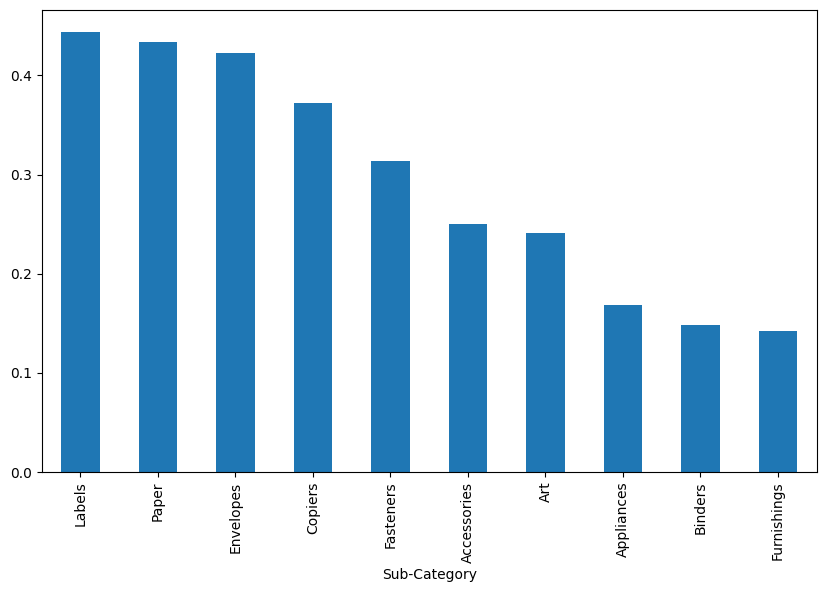

In [189]:
grouped= df.groupby('Sub-Category').agg(
    total_sales = ('Sales', 'sum'),
    total_profit =('Profit', 'sum'),
)
grouped['profit_margin'] = grouped['total_profit'] / grouped['total_sales']

result = grouped[grouped['total_profit'] > 0]\
    .sort_values(by= 'profit_margin', ascending= False)['profit_margin']
result.head(10).plot(kind= 'bar', figsize=(10, 6))

<Axes: xlabel='Category,Sub-Category'>

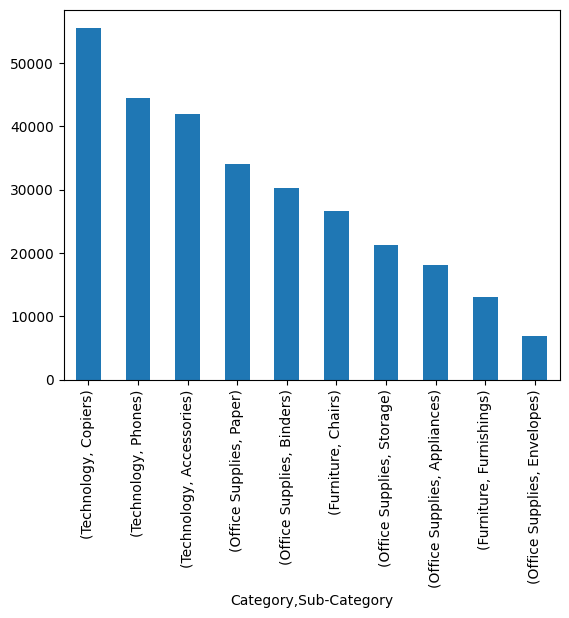

In [199]:
df.groupby(['Category', 'Sub-Category'])['Profit'].sum() \
  .sort_values(ascending=False) \
  .head(10) \
  .plot(kind='bar')

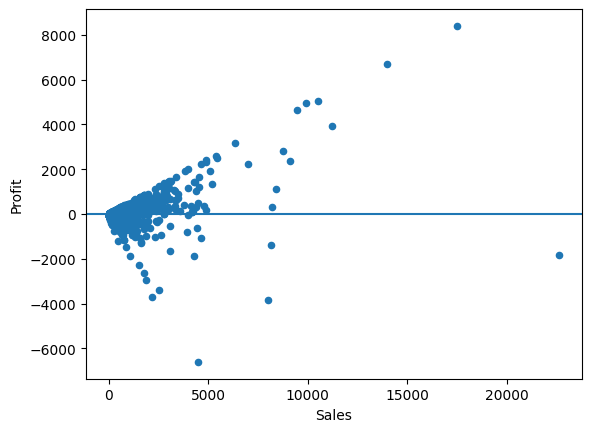

In [209]:
import matplotlib.pyplot as plt

df.plot(kind='scatter', x='Sales', y='Profit')
plt.axhline(0)
plt.show()

In [215]:
df[['Category', 'Sub-Category', 'Sales', 'Profit']].sort_values(by='Profit').head(10)

,Category,Sub-Category,Sales,Profit
7772,Technology,Machines,4499.985,-6599.9780
683,Technology,Machines,7999.980,-3839.9904
9774,Office Supplies,Binders,2177.584,-3701.8928
3011,Technology,Machines,2549.985,-3399.9800
4991,Office Supplies,Binders,1889.990,-2929.4845
3151,Technology,Machines,1799.994,-2639.9912
5310,Office Supplies,Binders,1525.188,-2287.7820
9639,Furniture,Tables,4297.644,-1862.3124
1199,Office Supplies,Binders,1088.792,-1850.9464
2697,Technology,Machines,22638.480,-1811.0784


In [216]:
grouped= df.groupby('Category').agg(
    total_sales = ('Sales', 'sum'),
    total_profit =('Profit', 'sum'),
)
grouped['profit_margin'] = grouped['total_profit'] / grouped['total_sales']

result = grouped[grouped['total_profit'] > 0]\
    .sort_values(by= 'profit_margin', ascending= False)
result

,total_sales,total_profit,profit_margin
Category,,,
Technology,836154.0330,145454.9481,0.173957
Office Supplies,719047.0320,122490.8008,0.170352
Furniture,741999.7953,18451.2728,0.024867


In [233]:
top3 = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(3)

percentage = (top3.sum() / df['Profit'].sum()) *100 

print(percentage)


49.6060295448247
